<a href="https://colab.research.google.com/github/Piedrafita101/Paquetes/blob/main/matricesinversas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmento 1: Repaso de introducción al álgebra lineal

In [2]:
import numpy as np
import torch

## Transposición de vectores

In [3]:
x = np.array([25, 2, 5])
x

array([25,  2,  5])

In [4]:
x.shape

(3,)

In [5]:
x = np.array([[25, 2, 5]])
x

array([[25,  2,  5]])

In [6]:
x.shape

(1, 3)

In [7]:
x.T

array([[25],
       [ 2],
       [ 5]])

In [8]:
x.T.shape

(3, 1)

In [9]:
x_p = torch.tensor([25, 2, 5])
x_p

tensor([25,  2,  5])

In [10]:
x_p.view(3, 1)

tensor([[25],
        [ 2],
        [ 5]])

#**Norma $L^2$**

In [11]:
x

array([[25,  2,  5]])

In [12]:
(25**2 + 2**2 + 5**2)**(1/2)

25.573423705088842

In [13]:
np.linalg.norm(x)

np.float64(25.573423705088842)

#### la siguiente línea de código fallará porque torch.norm() requiere que la entrada sea float y no integer
#### torch.norm(p)

In [14]:
torch.norm(torch.tensor([25, 2, 5.]))

tensor(25.5734)

##**Matrices**

In [15]:
X = np.array([[25, 2], [5, 26], [3, 7]])
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [16]:
X.shape

(3, 2)

In [17]:
X_p = torch.tensor([[25, 2], [5, 26], [3, 7]])
X_p

tensor([[25,  2],
        [ 5, 26],
        [ 3,  7]])

In [18]:
X_p.shape

torch.Size([3, 2])

##Trasposición de Matrices

In [19]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [20]:
X.T

array([[25,  5,  3],
       [ 2, 26,  7]])

In [21]:
X_p.T

tensor([[25,  5,  3],
        [ 2, 26,  7]])

## Multiplicación de Matrices

Se aplican escalares a cada elemento de la matriz

In [22]:
X*3

array([[75,  6],
       [15, 78],
       [ 9, 21]])

In [23]:
X*3+3

array([[78,  9],
       [18, 81],
       [12, 24]])

In [24]:
X_p*3

tensor([[75,  6],
        [15, 78],
        [ 9, 21]])

In [25]:
X_p*3+3

tensor([[78,  9],
        [18, 81],
        [12, 24]])

Usar el operador de multiplicación en dos tensores del mismo tamaño en PyTorch (o Numpy o TensorFlow) aplica operaciones de elemento a elemento. Este es el **producto Hadamard** (denotado por el operador $\odot$, por ejemplo, $A \odot B$) *no* **multiplicación de matrices**:

In [26]:
A = np.array([[3, 4], [5, 6], [7, 8]])
A

array([[3, 4],
       [5, 6],
       [7, 8]])

In [31]:
X

array([[25,  2],
       [ 5, 26],
       [ 3,  7]])

In [32]:
X*A

array([[ 75,   8],
       [ 25, 156],
       [ 21,  56]])

In [33]:
A_p = torch.tensor([[3, 4], [5, 6], [7, 8]])
A_p

tensor([[3, 4],
        [5, 6],
        [7, 8]])

In [34]:
X_p * A_p

tensor([[ 75,   8],
        [ 25, 156],
        [ 21,  56]])

Producto de Matriz por Vector:

In [35]:
b = np.array([1, 2])
b

array([1, 2])

In [36]:
np.dot(A, b)

array([11, 17, 23])

In [37]:
b_p = torch.tensor([1, 2])
b_p

tensor([1, 2])

In [38]:
torch.matmul(A_p, b_p)

tensor([11, 17, 23])

Multiplicación de matrices con dos matrices

In [39]:
B = np.array([[1, 9], [2, 0]])
B

array([[1, 9],
       [2, 0]])

In [40]:
np.dot(A, B)

array([[11, 27],
       [17, 45],
       [23, 63]])

In [41]:
B_p = torch.tensor([[1, 9], [2, 0]])
B_p

tensor([[1, 9],
        [2, 0]])

In [42]:
torch.matmul(A_p, B_p)

tensor([[11, 27],
        [17, 45],
        [23, 63]])

## **Inversa de una matriz**

In [43]:
X = np.array([[4, 2], [-5, -3]])
X

array([[ 4,  2],
       [-5, -3]])

In [44]:
Xinv = np.linalg.inv(X)
Xinv

array([[ 1.5,  1. ],
       [-2.5, -2. ]])

In [45]:
y = np.array([4, -7])
y

array([ 4, -7])

In [46]:
w = np.dot(Xinv, y)
w

array([-1.,  4.])

Demostrar que *y = Xw:*

In [47]:
np.dot(X, w)

array([ 4., -7.])

In [48]:
X_p = torch.tensor([[4, 2], [-5, -3]], dtype=torch.float32)
X_p

tensor([[ 4.,  2.],
        [-5., -3.]])

In [49]:
Xinv = torch.inverse(X_p)
Xinv

tensor([[ 1.5000,  1.0000],
        [-2.5000, -2.0000]])

In [50]:
y_p = torch.tensor([4, -7], dtype=torch.float32)
y_p

tensor([ 4., -7.])

In [52]:
w_p = torch.matmul(Xinv, y_p)
w_p

tensor([-1.,  4.])

In [53]:
torch.matmul(X_p, w_p)

tensor([ 4., -7.])

###**APLICACIÓN DE MATRICES**

In [27]:
 import numpy as np
 v = np.array([3, 1])
 v

array([3, 1])

**Descomposición propia**

**Transformación afín mediante aplicación matricial**

In [28]:
import matplotlib.pyplot as plt

In [29]:
def plot_vectors(vectors, colors):
  """
  Dibuja uno o más vectores in un plano de 2 dimensiones, con colores específicos cada uno.
  Argumentos
  ----------
  Vectores: lista de listas o de arrays
    Coordenadas de los vectores a dibujar. Por ejemplo, [[1, 3], [2, 2]]
    contiene dos vectores para dibujar, [1, 3] y [2, 2].
  Colores: lista
    Colores de los vectores. Además: ['red', 'blue'] mostrarán el primer vector en rojo y el segundo en azul.

  Ejemplo:
  plot_vectors([[1, 3], [2, 2]], ['red', 'blue'])
  plt.xlim(-1,4)
  plt.ylim(-1,4)
  plt.show()
  """
  plt.figure()
  plt.axvline(x=0, color='lightgray')
  plt.axhline(y=0, color='lightgray')

  for i in range(len(vectors)):
      x = np.concatenate([[0,0],vectors[i]])
      plt.quiver([x[0]], [x[1]], [x[2]], [x[3]],
                  angles='xy', scale_units='xy', scale=1, color=colors[i],)

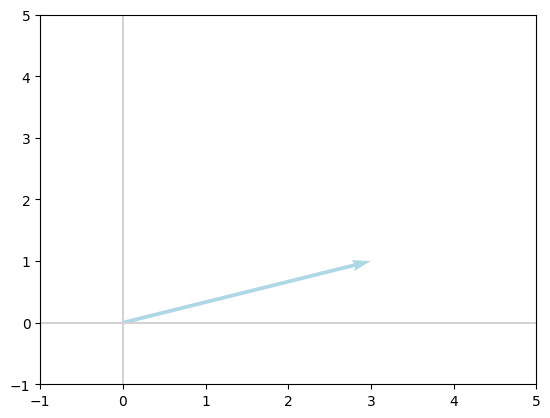

In [30]:
plot_vectors([v], ['lightblue'])
plt.xlim(-1,5)
_ = plt.ylim(-1,5)